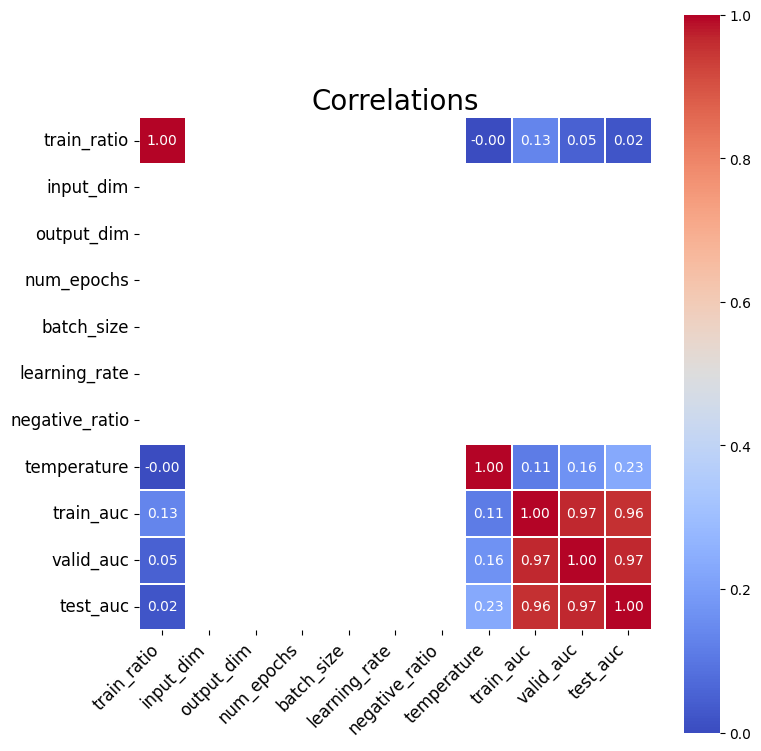

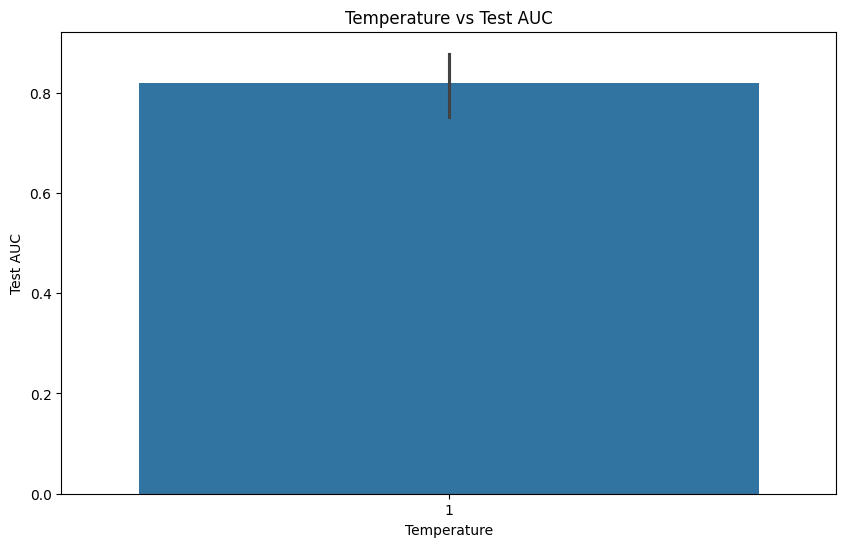

In [8]:
import os
import json
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    auc,
    f1_score,
    confusion_matrix,
    matthews_corrcoef
)
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn

# Define ContrastiveModel (ensure it matches your model definition)
class ContrastiveModel(nn.Module):
    def __init__(self, input_dim, projection_dim):
        super(ContrastiveModel, self).__init__()
        self.projection = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, projection_dim)
        )
    def forward(self, x):
        return self.projection(x)

# Updated evaluation function (as previously defined)
def evaluate_contrastive_model(model, embeddings, adjacency_matrix, loss_function, device):
    model.eval()
    with torch.no_grad():
        embeddings_tensor = torch.tensor(embeddings, dtype=torch.float32).to(device)
        projected_embeddings = model.projection(embeddings_tensor)
        projected_embeddings = nn.functional.normalize(projected_embeddings, p=2, dim=1)
        projected_embeddings = projected_embeddings.cpu().numpy()

        num_nodes = projected_embeddings.shape[0]

        # Get all possible pairs (upper triangular indices)
        triu_indices = np.triu_indices(num_nodes, k=1)

        # Get labels for all pairs in upper triangle
        adj_triu = adjacency_matrix[triu_indices]

        # Extract positive pairs (where adjacency_matrix == 1)
        positive_mask = adj_triu == 1
        positive_indices = (triu_indices[0][positive_mask], triu_indices[1][positive_mask])

        # Extract negative pairs (where adjacency_matrix == 0)
        negative_mask = adj_triu == 0
        negative_indices = (triu_indices[0][negative_mask], triu_indices[1][negative_mask])

        # Number of positive samples
        num_positive = len(positive_indices[0])

        # Sample equal number of negative samples
        np.random.seed(42)  # For reproducibility
        sampled_neg_indices = np.random.choice(len(negative_indices[0]), size=num_positive, replace=False)
        sampled_negative_indices = (negative_indices[0][sampled_neg_indices], negative_indices[1][sampled_neg_indices])

        # Combine positive and sampled negative indices
        idx1 = np.concatenate([positive_indices[0], sampled_negative_indices[0]])
        idx2 = np.concatenate([positive_indices[1], sampled_negative_indices[1]])

        # Corresponding labels
        true_labels = np.concatenate([np.ones(num_positive), np.zeros(num_positive)])

        # Compute similarity scores
        emb1 = projected_embeddings[idx1]
        emb2 = projected_embeddings[idx2]
        similarity_scores = np.sum(emb1 * emb2, axis=1)

        # Convert similarity scores to probabilities
        if loss_function == 'SNN':
            similarity_scores = 1 - np.array(similarity_scores)
        else:
            similarity_scores = np.array(similarity_scores)
        probabilities = 1 / (1 + np.exp(-similarity_scores))

        # Compute metrics
        auc_roc = roc_auc_score(true_labels, probabilities)
        precision, recall, thresholds = precision_recall_curve(true_labels, probabilities)
        auc_pr = auc(recall, precision)
        y_pred = (probabilities >= 0.5).astype(int)
        f1 = f1_score(true_labels, y_pred, zero_division=0)
        cm = confusion_matrix(true_labels, y_pred)
        mcc = matthews_corrcoef(true_labels, y_pred)

        metrics = {
            'auc_roc': auc_roc,
            'auc_pr': auc_pr,
            'f1_score': f1,
            'confusion_matrix': cm,
            'mcc': mcc,
            'precision_curve': precision,
            'recall_curve': recall,
            'thresholds': thresholds,
            'true_labels': true_labels,
            'probabilities': probabilities
        }
        return metrics

# Function to load ground truth GRN
def load_ground_truth_grn(file_path, num_genes):
    H = np.zeros((num_genes, num_genes))
    with open(file_path, 'r') as f:
        for line in f:
            source, target = map(int, line.strip().split(','))
            H[source, target] = 1
    return H

# Sampling functions (ensure they match those used during training)
def sample_partial_grn(H, sample_ratio=0.8):
    num_edges = np.sum(H)
    num_sample = int(num_edges * sample_ratio)
    edge_indices = np.argwhere(H == 1)
    np.random.shuffle(edge_indices)
    sampled_edges = edge_indices[:num_sample]
    G = np.zeros_like(H)
    G[tuple(zip(*sampled_edges))] = 1
    return G

def split_train_valid(G, train_ratio=0.875):
    edge_indices = np.argwhere(G == 1)
    num_edges = len(edge_indices)
    num_train = int(num_edges * train_ratio)
    np.random.shuffle(edge_indices)
    train_edges = edge_indices[:num_train]
    valid_edges = edge_indices[num_train:]
    G_train = np.zeros_like(G)
    G_valid = np.zeros_like(G)
    G_train[tuple(zip(*train_edges))] = 1
    G_valid[tuple(zip(*valid_edges))] = 1
    return G_train, G_valid

def get_test_set(H, G):
    G_test = H - G
    G_test[G_test < 0] = 0
    return G_test

# Load embeddings
embeddings_path = './results/cl/DS3/pca_embeddings.npy'
embeddings = np.load(embeddings_path)
input_dim = embeddings.shape[1]
num_genes = embeddings.shape[0]

# Load ground truth adjacency matrix H
gt_grn_file = '../SERGIO/data_sets/De-noised_1200G_9T_300cPerT_6_DS3/gt_GRN.csv'
H = load_ground_truth_grn(gt_grn_file, num_genes)

# Base directory for the models
base_dir = './logs/pca_SNN_DS3/'

# List of model versions
model_versions = [d for d in os.listdir(base_dir) if d.startswith('version_')]

results = []

for version in model_versions:
    version_dir = os.path.join(base_dir, version)
    params_path = os.path.join(version_dir, 'params.json')
    model_path = os.path.join(version_dir, 'cl_model_pca_SNN.pth')
    
    # Load parameters
    with open(params_path, 'r') as f:
        params = json.load(f)
    
    # Load model
    model = ContrastiveModel(input_dim=params['input_dim'], projection_dim=params['output_dim'])
    model.load_state_dict(torch.load(model_path))
    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    # Reconstruct G_train, G_valid, G_test
    np.random.seed(42)  # Ensure reproducibility
    valid_ratio = (1 - params['train_ratio']) / 2
    test_ratio = valid_ratio
    total_sample_ratio = params['train_ratio'] + valid_ratio
    G = sample_partial_grn(H, sample_ratio=total_sample_ratio)
    G_train, G_valid = split_train_valid(G, train_ratio=params['train_ratio'] / total_sample_ratio)
    G_test = get_test_set(H, G)
    
    # Evaluate the model
    train_metrics = evaluate_contrastive_model(model, embeddings, G_train, params['loss_function'], device)
    valid_metrics = evaluate_contrastive_model(model, embeddings, G_valid, params['loss_function'], device)
    test_metrics = evaluate_contrastive_model(model, embeddings, G_test, params['loss_function'], device)
    
    # Collect results
    result = {
        'version': version,
        'train_auc_roc': train_metrics['auc_roc'],
        'train_auc_pr': train_metrics['auc_pr'],
        'train_f1_score': train_metrics['f1_score'],
        'train_mcc': train_metrics['mcc'],
        'valid_auc_roc': valid_metrics['auc_roc'],
        'valid_auc_pr': valid_metrics['auc_pr'],
        'valid_f1_score': valid_metrics['f1_score'],
        'valid_mcc': valid_metrics['mcc'],
        'test_auc_roc': test_metrics['auc_roc'],
        'test_auc_pr': test_metrics['auc_pr'],
        'test_f1_score': test_metrics['f1_score'],
        'test_mcc': test_metrics['mcc'],
        **params  # Include all parameters for analysis
    }
    results.append(result)

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Save results to CSV for future analysis
results_df.to_csv('model_evaluation_results.csv', index=False)

# Analyze results
best_models = results_df.sort_values(by='test_auc_pr', ascending=False)
print(best_models.head())

# Plotting example: Test AUPR vs. Temperature
plt.figure(figsize=(10, 6))
sns.barplot(x='temperature', y='test_auc_pr', data=results_df)
plt.title("Temperature vs Test AUPR")
plt.xlabel("Temperature")
plt.ylabel("Test AUPR")
plt.show()

In [4]:
!pwd

/scratch/ab9738/dfdl_imputation/contrastive_learning
